# Avaliação final e explicabilidade — preços, erros e limites de uso

**Moeda adotada:** dólar americano (USD), por premissa do projeto baseada no contexto de Seattle. Não houve conversão cambial nem alteração dos valores. A fonte não confirmou explicitamente a moeda. Preços e erros monetários estão em USD; percentuais, R² e contribuições SHAP em log mantêm suas próprias escalas.

## Objetivo
Medir o desempenho da configuração escolhida no notebook 05 em vendas posteriores reservadas para teste, entender onde ela erra e explicar suas previsões. Depois, gerar os preços dos 100 exemplos futuros com o mesmo modelo avaliado.

**Protocolo:** treinar LightGBM e o baseline Ridge com as 17.191 vendas de treino e validação; avaliar nas 4.331 vendas de teste, sem ajustar parâmetros em resposta aos resultados. As 91 vendas antigas com IDs presentes no teste continuam excluídas. Reexecuções reaproveitam os modelos e as previsões salvos se a configuração e os dados forem os mesmos; não são novos testes independentes.

**O que vamos observar:** MAE, RMSE, R², mediana do erro, erros percentuais, faixas de preço, CEP e características dos imóveis. ±10% e ±20% são referências ilustrativas, não limites aprovados pelo negócio. A inspeção do teste não será usada para escolher outras colunas ou retreinar aqui.

**Limitações conhecidas:** a EDA examinou todo o histórico; a origem e a disponibilidade dos indicadores demográficos na época das vendas continuam sem confirmação. O teste está separado da modelagem, mas não foi completamente desconhecido durante a exploração. Os exemplos futuros têm sobreposição de características com o histórico e não comprovam generalização.

In [1]:
# Prepara bibliotecas, pastas e limites de execução.
import os
for nome in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    os.environ[nome] = "2"
from pathlib import Path
from time import perf_counter
from datetime import datetime, timezone
import json
import hashlib
import platform
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import lightgbm
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from threadpoolctl import threadpool_limits
from IPython.display import display as exibir
%matplotlib inline

PASTA_PROJETO = Path.cwd()
if not (PASTA_PROJETO / "data/processed").is_dir():
    PASTA_PROJETO = PASTA_PROJETO.parent
PASTA_DADOS = PASTA_PROJETO / "data/processed"
PASTA_RESULTADOS = PASTA_PROJETO / "reports/metrics"
PASTA_GRAFICOS = PASTA_PROJETO / "reports/figures"
PASTA_PREVISOES = PASTA_PROJETO / "reports/predictions"
PASTA_ARTEFATOS = PASTA_PROJETO / "artifacts"
for pasta in [PASTA_RESULTADOS, PASTA_GRAFICOS, PASTA_PREVISOES, PASTA_ARTEFATOS]:
    pasta.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
SEMENTE = 42
LIMITE_THREADS = 2
AMOSTRA_IMPORTANCIA = 600
REPETICOES_IMPORTANCIA = 3

def hash_arquivo(caminho):
    return hashlib.sha256(caminho.read_bytes()).hexdigest()

print("Dois ajustes finais; explicabilidade em 600 vendas e três exemplos individuais.")

Dois ajustes finais; explicabilidade em 600 vendas e três exemplos individuais.


**O que essa preparação faz:** limita a execução a duas threads e evita uma nova busca de modelos. A importância será estimada em uma amostra aleatória de 600 vendas para reduzir custo; as métricas finais usarão todo o teste. As tabelas exibem o texto completo, sem `.style` ou dependências adicionais.

## 1. Conferindo configuração, datas e separação dos imóveis

In [2]:
# Confere a configuração congelada e reconstrói as partições originais.
caminho_configuracao = PASTA_ARTEFATOS / "configuracao_modelo_selecionado.json"
configuracao = json.loads(caminho_configuracao.read_text(encoding="utf-8"))
contrato = json.loads((PASTA_DADOS / "contrato_features.json").read_text(encoding="utf-8"))
protocolo = json.loads((PASTA_RESULTADOS / "baseline_protocolo.json").read_text(encoding="utf-8"))
if configuracao['modelo'] != 'LightGBM':
    raise ValueError('Este notebook explica a configuração LightGBM congelada.')
if not (configuracao["transformacao_alvo_log1p"] is True):
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
for nome, versao in {"scikit_learn": sklearn.__version__, "lightgbm": lightgbm.__version__,
                     "numpy": np.__version__, "pandas": pd.__version__}.items():
    if configuracao['versoes'][nome] != versao:
        raise ValueError(f"Arquivo ou versão incompatível: {nome}")
for nome, resumo in configuracao["source_sha256"].items():
    if hash_arquivo(PASTA_PROJETO / nome) != resumo:
        raise ValueError(f"Arquivo ou versão incompatível: {nome}")
variaveis = pd.read_csv(PASTA_DADOS / "features_historico.csv", dtype={"zipcode": "string"})
identificacao = pd.read_csv(PASTA_DADOS / "identificacao_alvo_historico.csv", dtype={"id": "string"})
divisao = pd.read_csv(PASTA_DADOS / "split_manifest.csv", dtype={"id": "string"})
if variaveis.columns.tolist() != contrato['colunas_saida_ordenadas']:
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
if identificacao['linha_origem'].tolist() != list(range(len(variaveis))):
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
if divisao['source_row'].tolist() != identificacao['linha_origem'].tolist():
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
if not (divisao["id"].equals(identificacao["id"])):
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
datas = pd.to_datetime(identificacao["date"], format="%Y%m%dT%H%M%S")
if not (pd.to_datetime(divisao["date"]).equals(datas)):
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
if divisao['partition'].value_counts().to_dict() != protocolo['split_counts']:
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
treino = divisao.loc[divisao["partition"].eq("train_validation"), "source_row"].to_numpy()
teste = divisao.loc[divisao["partition"].eq("test"), "source_row"].to_numpy()
if not (set(treino).isdisjoint(teste)):
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
if not (set(identificacao.loc[treino, "id"]).isdisjoint(identificacao.loc[teste, "id"])):
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
if not (datas.loc[treino].max() < datas.loc[teste].min()):
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
colunas_modelo = configuracao["colunas_ordenadas"]
colunas_baseline = protocolo["features"]
if colunas_modelo != contrato['grupos_candidatos'][configuracao['grupo']]:
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
precos = identificacao["price"]
if not (precos.gt(0).all() and np.isfinite(precos).all()):
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
exibir(pd.DataFrame([
    {"parte": "Treino final", "vendas": len(treino), "inicio": datas.loc[treino].min(), "fim": datas.loc[treino].max()},
    {"parte": "Teste final", "vendas": len(teste), "inicio": datas.loc[teste].min(), "fim": datas.loc[teste].max()},
]))

,parte,vendas,inicio,fim
0,Treino final,17191,2014-05-02,2015-03-09
1,Teste final,4331,2015-03-10,2015-05-27


**Por que conferir:** o `assert` interrompe a execução se os arquivos, a ordem das linhas ou a separação dos imóveis não forem os mesmos das etapas anteriores. Ele não altera os dados. Treino e validação agora são reunidos para o ajuste final, porque as escolhas já foram encerradas. Nenhum preço do teste participa desse ajuste.

**Resultado:** o treino final cobre 02/05/2014 a 09/03/2015; o teste cobre 10/03/2015 a 27/05/2015. As 17.191 vendas de treino e 4.331 de teste não compartilham IDs. Essa é uma avaliação de vendas posteriores de imóveis não vistos no treino, dentro da região já representada no histórico.

## 2. Treinando a configuração congelada e o baseline

In [3]:
# Reconstrói os mesmos pipelines, sem mudar seus hiperparâmetros.
def construir_modelo(colunas, parametros, linear=False):
    numericas = [coluna for coluna in colunas if coluna != "zipcode"]
    etapas = [("imputacao", SimpleImputer(strategy="median", keep_empty_features=True))]
    if linear:
        etapas.append(("escala", StandardScaler()))
    preparacao = ColumnTransformer([
        ("numericas", Pipeline(etapas), numericas),
        ("categoricas", Pipeline([
            ("imputacao", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
            ("codificacao", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=linear)),
        ]), ["zipcode"]),
    ], sparse_threshold=1.0 if linear else 0.0, n_jobs=1)
    if linear:
        estimador = Ridge(**parametros)
    else:
        preparacao.set_output(transform="pandas")
        estimador = LGBMRegressor(**parametros, random_state=configuracao["random_state"], n_jobs=configuracao["threads"])
    pipeline = Pipeline([("preparacao", preparacao), ("modelo", estimador)])
    return pipeline if linear else TransformedTargetRegressor(regressor=pipeline, func=np.log1p, inverse_func=np.expm1)

if not (configuracao["pipeline"] == {
    "numeric_imputer": "median", "keep_empty_features": True, "numeric_scaler": None,
    "categorical_columns": ["zipcode"], "categorical_imputer": "constant_UNKNOWN",
    "onehot_drop": "first", "onehot_handle_unknown": "ignore", "sparse": False,
    "boosting_early_stopping": False, "transform_output": "pandas",
}):
    raise ValueError('Configuração ou artefato incompatível com a avaliação.')
parametros_ridge = {"alpha": protocolo["baseline_parameters"]["ridge_alpha"],
                    "solver": protocolo["baseline_parameters"]["ridge_solver"],
                    "tol": protocolo["baseline_parameters"]["ridge_tol"]}
caminho_registro = PASTA_RESULTADOS / "avaliacao_registro.json"
caminho_modelo = PASTA_ARTEFATOS / "modelo_avaliado.joblib"
caminho_ridge = PASTA_ARTEFATOS / "ridge_avaliado.joblib"
caminho_previsoes = PASTA_PREVISOES / "avaliacao_teste.csv"
# Ignora apenas medições de execução; mantém dados e decisões do experimento.
def assinatura_experimento(configuracao, protocolo):
    conteudo = {
        "configuracao": {chave: valor for chave, valor in configuracao.items() if chave != "orcamento"},
        "protocolo_baseline": {chave: valor for chave, valor in protocolo.items() if chave != "resources"},
    }
    texto = json.dumps(conteudo, sort_keys=True, ensure_ascii=False, separators=(",", ":"))
    return hashlib.sha256(texto.encode("utf-8")).hexdigest()

**Organização:** as funções acima definem a preparação. O bloco seguinte confere os registros salvos antes de reaproveitá-los; nenhuma configuração é escolhida pelo teste.

In [4]:
# Executa o reaproveitamento após conferir a preparação.
assinatura_semantica = assinatura_experimento(configuracao, protocolo)
assinatura = {"configuracao": hash_arquivo(caminho_configuracao),
              "protocolo_baseline": hash_arquivo(PASTA_RESULTADOS / "baseline_protocolo.json"),
              "fontes": configuracao["source_sha256"]}
if caminho_registro.exists():
    registro = json.loads(caminho_registro.read_text(encoding="utf-8"))
    # Registros antigos exigem igualdade integral; novos toleram apenas medições diferentes.
    compativel = (registro["assinatura_semantica"] == assinatura_semantica
                  if "assinatura_semantica" in registro else registro["assinatura"] == assinatura)
    if not compativel:
        raise ValueError("Dados ou decisões do experimento diferem da avaliação salva. "
                         "Preserve o registro e investigue a mudança antes de avaliar novamente.")
    for nome, resumo in registro["artefatos_sha256"].items():
        if hash_arquivo(PASTA_PROJETO / nome) != resumo:
            raise ValueError(f"Arquivo ou versão incompatível: {nome}")
    modelo = joblib.load(caminho_modelo)
    ridge = joblib.load(caminho_ridge)
    resultados = pd.read_csv(caminho_previsoes, dtype={"id": "string", "zipcode": "string"})
    print("Avaliação já registrada: modelos e previsões reaproveitados, sem novo treino.")
else:
    modelo = construir_modelo(colunas_modelo, configuracao["parametros"])
    ridge = construir_modelo(colunas_baseline, parametros_ridge, linear=True)
    inicio = perf_counter()
    with threadpool_limits(limits=LIMITE_THREADS):
        modelo.fit(variaveis.loc[treino, colunas_modelo], precos.loc[treino])
        ridge.fit(variaveis.loc[treino, colunas_baseline], precos.loc[treino])
        previsoes = modelo.predict(variaveis.loc[teste, colunas_modelo])
        previsoes_ridge = ridge.predict(variaveis.loc[teste, colunas_baseline])
    if not (np.isfinite(previsoes).all() and np.isfinite(previsoes_ridge).all()):
        raise ValueError('Configuração ou artefato incompatível com a avaliação.')
    resultados = pd.DataFrame({"source_row": teste, "id": identificacao.loc[teste, "id"].to_numpy(),
        "date": datas.loc[teste].astype(str).to_numpy(), "zipcode": variaveis.loc[teste, "zipcode"].to_numpy(),
        "price": precos.loc[teste].to_numpy(), "predicted_price": previsoes, "ridge_prediction": previsoes_ridge})
    resultados.to_csv(caminho_previsoes, index=False)
    joblib.dump(modelo, caminho_modelo)
    joblib.dump(ridge, caminho_ridge)
    registro = {"versao": "avaliacao_v1", "test_evaluated": True, "assinatura": assinatura,
        "assinatura_semantica": assinatura_semantica,
        "data_utc": datetime.now(timezone.utc).isoformat(), "treino": len(treino), "teste": len(teste),
        "ajustes": 2, "segundos_ajuste_previsao_exportacao": perf_counter() - inicio,
        "artefatos_sha256": {str(p.relative_to(PASTA_PROJETO)).replace(chr(92), "/"): hash_arquivo(p)
                            for p in [caminho_modelo, caminho_ridge, caminho_previsoes]}}
    caminho_registro.write_text(json.dumps(registro, indent=2, ensure_ascii=False), encoding="utf-8")
    print("Dois modelos ajustados no treino e avaliação registrada. O teste não orientou ajustes.")
if resultados['source_row'].tolist() != teste.tolist():
    raise ValueError('Configuração ou artefato incompatível com a avaliação.')
np.testing.assert_allclose(resultados["price"], precos.loc[teste])

Avaliação já registrada: modelos e previsões reaproveitados, sem novo treino.


**Por que fazer isso:** a comparação é entre o candidato escolhido e uma referência já definida, nas mesmas vendas. Ridge usa 18 entradas; LightGBM usa 50. Portanto, o ganho combina algoritmo, entradas e parâmetros, não isola só o algoritmo. Salvamos o modelo efetivamente avaliado. A configuração do 05 permanece como registro anterior ao teste; o registro desta etapa informa que o teste foi avaliado.

**Resultado:** os dois ajustes e a exportação inicial levaram aproximadamente 0,85 segundo nesta execução. Esse tempo não inclui a abertura do notebook ou toda a explicabilidade. Não houve novas tentativas de Optuna. Nas reexecuções, a mensagem informa o reaproveitamento da avaliação registrada.

**Reexecução segura:** tempos e consumo de memória podem mudar a cada execução dos notebooks 04 e 05. A assinatura compara o conteúdo das decisões e dos dados, ignorando somente os blocos de medições `orcamento` e `resources`. Parâmetros, colunas, versões, transformações e hashes dos dados continuam protegidos; os arquivos dos modelos e das previsões também são conferidos. Quando compatíveis, os modelos salvos são carregados sem novo treinamento.


## 3. Medindo o erro e dando significado aos números

In [5]:
# Calcula métricas na escala original, sem cortar previsões ou erros.
def calcular_metricas(real, previsto):
    real, previsto = np.asarray(real), np.asarray(previsto)
    # Evita percentuais inválidos e rejeita dados não finitos.
    if (real <= 0).any() or not np.isfinite(real).all() or not np.isfinite(previsto).all():
        raise ValueError("Métricas percentuais exigem preços positivos e valores finitos.")
    erro = previsto - real
    absoluto = np.abs(erro)
    percentual = absoluto / np.asarray(real)
    return {"MAPE_pct": 100 * percentual.mean(), "MAE": absoluto.mean(), "RMSE": root_mean_squared_error(real, previsto),
        "R2": r2_score(real, previsto), "erro_mediano": np.median(absoluto),
        "erro_p90": np.quantile(absoluto, 0.9), "erro_percentual_mediano": 100 * np.median(percentual),
        "dentro_10_pct": 100 * np.mean(percentual <= 0.10), "dentro_20_pct": 100 * np.mean(percentual <= 0.20),
        "vies_medio": erro.mean(), "previsoes_nao_positivas": int((np.asarray(previsto) <= 0).sum())}
metricas = pd.DataFrame([
    {"modelo": "Ridge", **calcular_metricas(resultados["price"], resultados["ridge_prediction"])},
    {"modelo": "LightGBM", **calcular_metricas(resultados["price"], resultados["predicted_price"])},
])
metricas.to_csv(PASTA_RESULTADOS / "avaliacao_metricas.csv", index=False)
exibir(metricas.set_index("modelo").T.round(2))

modelo,Ridge,LightGBM
MAPE_pct,20.17,12.77
MAE,102170.13,74089.41
RMSE,172212.44,129025.96
R2,0.78,0.88
erro_mediano,72542.24,44655.82
erro_p90,193378.84,158094.36
erro_percentual_mediano,15.28,10.03
dentro_10_pct,33.92,49.92
dentro_20_pct,61.37,80.56
vies_medio,-36637.55,-45704.70


**Como interpretar:** MAE é a média do tamanho dos erros. Erro mediano é o ponto em que metade dos erros fica abaixo e metade acima; o percentil 90 informa o valor abaixo do qual ficam aproximadamente 90% dos erros. RMSE pesa mais os erros grandes. R² não é percentual de acerto. O viés usa **previsto − real**: negativo indica subestimação média.

**Por que fizemos:** o MAE sozinho não informa se o erro é aceitável em imóveis de diferentes preços. Os percentuais dentro de ±10% e ±20% ajudam a leitura, mas sua aceitação depende do uso pretendido. Não aplicamos um limite de negócio inventado.

**Resultado:** o LightGBM apresentou MAE de **74.089**, contra **102.170** do Ridge no mesmo teste: redução de **27,48%**. O RMSE foi 129.026 e o R², 0,877. O erro mediano de 44.656 é menor que o MAE, indicando que erros grandes elevam a média. Aproximadamente 90% dos erros absolutos ficaram até 158.094.

**Leitura prática:** 49,92% das previsões ficaram dentro de ±10% do preço real e 80,56% dentro de ±20%. O erro percentual mediano foi 10,03%. Nenhuma previsão do LightGBM foi não positiva; Ridge apresentou 13. O viés médio do LightGBM foi −45.705, mostrando subestimação média, apesar de melhorar o MAE em relação ao baseline.

O MAE de teste ficou **19,02% acima** da média de validação do notebook 05 (62.249). São períodos e tamanhos de treino diferentes; isso não demonstra sozinho a causa da piora. **Hipótese:** mudanças no perfil das vendas e o otimismo da seleção podem contribuir. O resultado ainda não permite dizer que o erro está dentro de um limite aceitável para o negócio.

**Complemento da auditoria — escala do erro e diferença fora do treino**

No teste, o preço médio é **554.588,88** e a mediana é **465.000,00**. O MAE de **74.089,41** equivale a **13,36% do preço médio**. Essa razão ajuda a entender a escala, mas não é MAPE nem significa que cada casa teve esse erro percentual. O erro percentual mediano por imóvel foi **10,03%**. Os valores são apresentados em USD, por premissa do projeto, sem conversão cambial.

Ao reaplicar o modelo salvo às próprias vendas de treino, o MAE foi **41.185,22**. A média de validação foi **62.249,43** e o teste foi **74.089,41**. O desempenho piora fora do treino; não foi demonstrada ausência de overfitting. Mudanças de período e composição dos imóveis também podem contribuir, por isso esses números não identificam sozinhos a causa.

Não há tolerância de negócio aprovada. Melhorar o Ridge não basta para aceitar precificação automática, especialmente com a subestimação dos imóveis caros. Detalhes e verificações reproduzíveis estão na [auditoria do projeto](../docs/project_audit.md).

### MAPE: erro percentual médio como complemento

**Resultado no teste:** LightGBM teve **MAPE de 12,77%**, contra **20,17% do Ridge**, nas mesmas 4.331 vendas. Para cada imóvel, dividimos o erro absoluto pelo preço real, multiplicamos por 100 e depois calculamos a média. Isso expressa o tamanho médio do erro relativo; não significa 87,23% de acerto nem uma garantia para cada previsão.

**Por que incluir:** o MAE de USD 74.089,41 informa a escala monetária; o MAPE facilita comparar erros relativos entre preços diferentes. Ele também é diferente dos **10,03% de erro percentual mediano** e dos **13,36% da razão entre MAE e preço médio**.

**Cuidados e decisão:** o mesmo erro em USD pesa mais em imóveis baratos. Preços próximos de zero podem distorcer o MAPE; no teste, o menor preço é USD 81.000. Mantemos **MAE como critério principal de seleção**. MAPE foi acrescentado às previsões existentes, sem novos treinamentos ou escolha pelo teste; não há tolerância de negócio aprovada.

Na validação do candidato final, a média do MAPE das três janelas é **11,97%**. Agrupando todas as vendas de validação, é **11,92%**: as quantidades de vendas por janela diferem. Para comparar períodos com peso igual, usamos o primeiro valor.


## 4. Visualizando acertos, dispersão e erros grandes

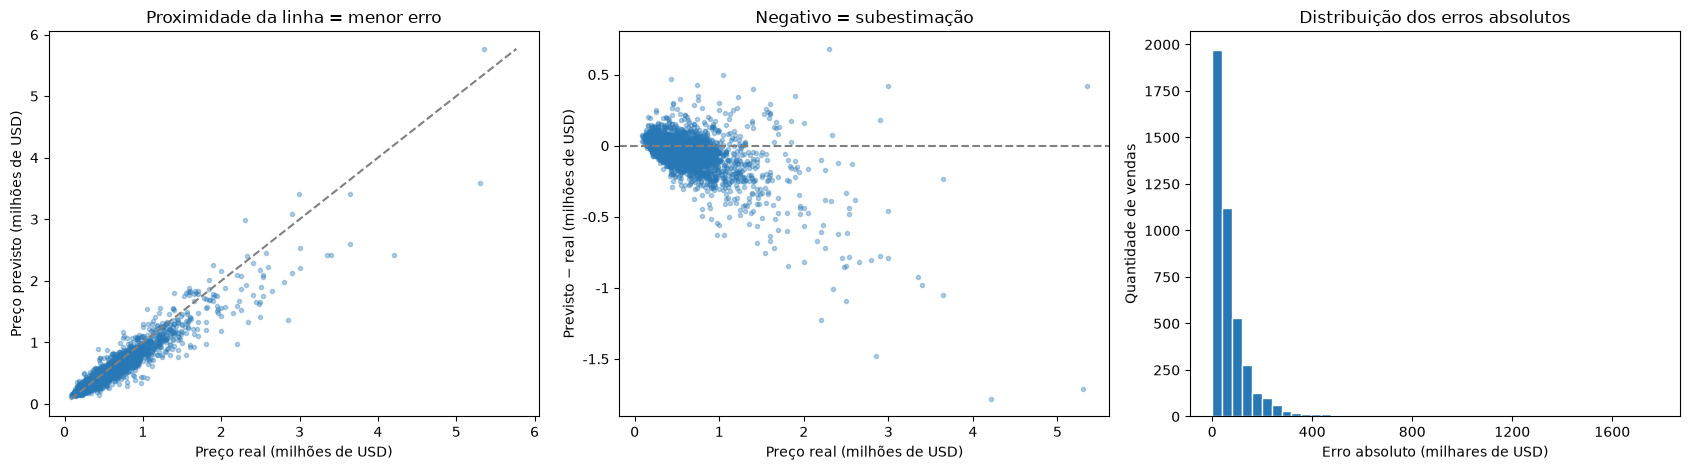

In [6]:
# Mostra todas as vendas de teste e mantém os extremos visíveis.
resultados["erro"] = resultados["predicted_price"] - resultados["price"]
resultados["erro_absoluto"] = resultados["erro"].abs()
resultados["erro_percentual"] = 100 * resultados["erro_absoluto"] / resultados["price"]
figura, eixos = plt.subplots(1, 3, figsize=(17, 4.8))
eixos[0].scatter(resultados["price"], resultados["predicted_price"], s=9, alpha=0.35, color="#2878B5")
limites = [min(resultados["price"].min(), resultados["predicted_price"].min()),
           max(resultados["price"].max(), resultados["predicted_price"].max())]
eixos[0].plot(limites, limites, color="gray", linestyle="--")
eixos[0].set(xlabel="Preço real", ylabel="Preço previsto", title="Proximidade da linha = menor erro")
eixos[1].scatter(resultados["price"], resultados["erro"], s=9, alpha=0.35, color="#2878B5")
eixos[1].axhline(0, color="gray", linestyle="--")
eixos[1].set(xlabel="Preço real", ylabel="Previsto − real", title="Negativo = subestimação")
eixos[2].hist(resultados["erro_absoluto"], bins=45, color="#2878B5", edgecolor="white")
eixos[2].set(xlabel="Erro absoluto", ylabel="Quantidade de vendas", title="Distribuição dos erros absolutos")
for eixo in eixos:
    eixo.grid(False)
    eixo.ticklabel_format(style="plain", axis="both")
# Abrevia os eixos monetários para evitar números sobrepostos.
from matplotlib.ticker import FuncFormatter, MaxNLocator
for eixo in eixos[:2]:
    eixo.xaxis.set_major_formatter(FuncFormatter(lambda valor, posicao: f"{valor / 1e6:g}"))
    eixo.yaxis.set_major_formatter(FuncFormatter(lambda valor, posicao: f"{valor / 1e6:g}"))
    eixo.set_xlabel("Preço real (milhões de USD)")
eixos[0].set_ylabel("Preço previsto (milhões de USD)")
eixos[1].set_ylabel("Previsto − real (milhões de USD)")
eixos[2].xaxis.set_major_formatter(FuncFormatter(lambda valor, posicao: f"{valor / 1000:g}"))
eixos[2].xaxis.set_major_locator(MaxNLocator(5))
eixos[2].set_xlabel("Erro absoluto (milhares de USD)")
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "avaliacao_erros.png", dpi=150)
plt.show()

**Como ler:** no primeiro gráfico, a diagonal indica previsão igual ao preço real. No segundo, pontos abaixo do zero são preços subestimados. A linha é uma referência de erro zero, não uma linha de grade. No histograma, barras altas mostram erros frequentes; a cauda mostra erros menos comuns e maiores.

**Hipótese:** vendas com características raras ou preços extremos podem apresentar erros maiores por terem menos exemplos semelhantes no treino. O gráfico não comprova essa causa; vamos observar os segmentos e os casos individuais.

**Resultado:** o histograma concentra vendas com erros menores e apresenta uma cauda longa. A tabela dos maiores erros chega a aproximadamente 1,78 milhão. No gráfico central, aparecem subestimações grandes em imóveis caros. Os dois primeiros gráficos usam milhões nos eixos; o histograma usa milhares de USD, sem excluir extremos. Essa dificuldade precisa acompanhar a comunicação do MAE médio.

## 5. Erros por preço, CEP e características dos imóveis

,vendas,preco_mediano,MAE,MAPE_pct,erro_mediano,erro_percentual_mediano,vies_medio,dentro_20_pct
faixa_preco,,,,,,,,
Até 300 mil,815,250000.0,34065.04,15.08,26730.15,11.08,4370.44,76.81
300 a 600 mil,2178,432000.0,50307.25,11.46,39016.51,9.29,-27839.85,84.57
600 mil a 1 milhão,1023,725000.0,93704.06,12.29,74324.81,9.96,-69292.52,80.16
Acima de 1 milhão,315,1310000.0,278380.19,17.39,219357.73,15.86,-222182.56,63.81


,vendas,preco_mediano,MAE,MAPE_pct,erro_mediano,erro_percentual_mediano,vies_medio,dentro_20_pct
zipcode,,,,,,,,
98038,133,359500.0,45396.89,11.05,34691.52,9.27,-22052.04,87.97
98042,130,305500.0,31420.19,10.04,24749.76,8.34,-17797.36,90.00
98115,123,600000.0,99449.38,14.25,71285.60,11.65,-70413.19,73.98
98118,122,420000.0,91883.61,19.41,75862.24,17.16,-66440.77,54.92
98103,121,600000.0,91406.11,14.67,69468.34,12.40,-59996.40,74.38
98117,111,546500.0,76574.51,12.77,66316.72,12.02,-55355.68,80.18
98133,104,415000.0,57606.64,12.96,40968.86,11.35,-43794.35,83.65
98058,103,347000.0,37199.41,11.30,28204.14,7.84,-17699.99,84.47
98052,99,636000.0,67267.28,9.78,52428.94,8.13,-41630.81,94.95


,vendas,preco_mediano,MAE,MAPE_pct,erro_mediano,erro_percentual_mediano,vies_medio,dentro_20_pct
grade,,,,,,,,
4,7,217000.0,78689.60,48.03,75001.56,36.23,21595.86,14.29
5,54,275500.0,70227.59,20.85,45612.24,18.94,-48389.98,53.70
6,442,299975.0,60746.54,18.10,42646.87,14.38,-35702.65,63.80
7,1816,399000.0,57544.45,13.07,41048.14,10.95,-36488.33,80.78
8,1217,530000.0,66403.89,10.94,42227.41,8.47,-39989.37,85.46
9,499,750000.0,92829.31,10.29,54908.11,7.95,-55736.73,85.97
10,207,938000.0,146066.32,11.29,83605.48,8.30,-78819.52,86.47
11,72,1373500.0,232539.07,13.15,169022.21,9.66,-156236.41,76.39
12,16,2225000.0,629240.59,21.29,515454.81,24.61,-524485.66,43.75


,vendas,preco_mediano,MAE,MAPE_pct,erro_mediano,erro_percentual_mediano,vies_medio,dentro_20_pct
waterfront,,,,,,,,
0,4299,463828.0,71855.40,12.66,44423.06,9.97,-44584.74,80.88
1,32,1576000.0,374214.27,27.28,339807.50,24.65,-196163.86,37.50


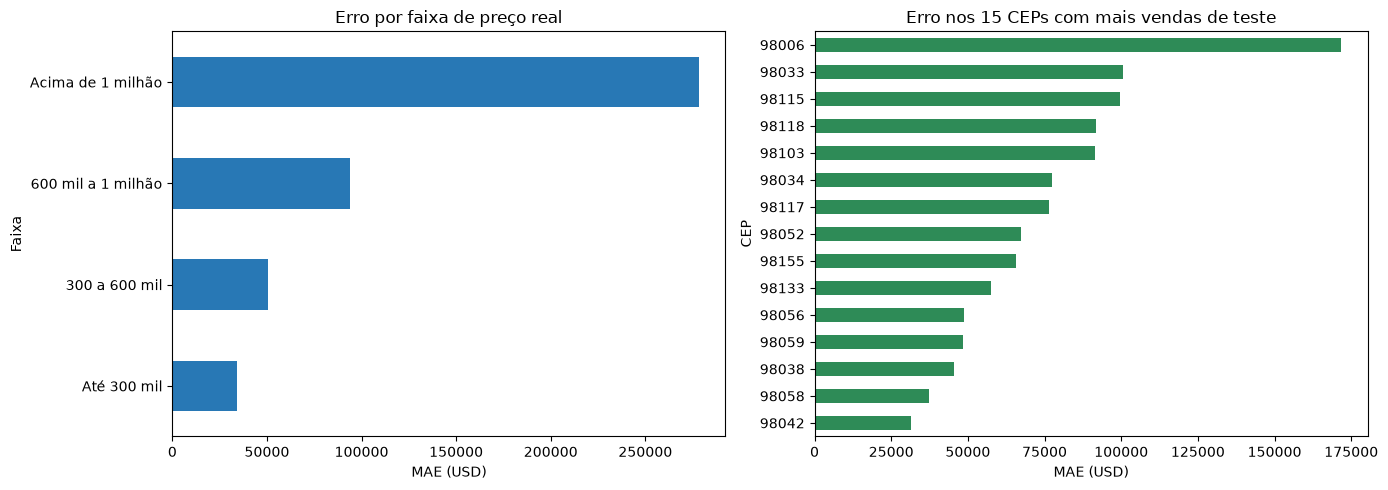

In [7]:
# Usa faixas descritivas fixas e informa o tamanho de cada grupo.
resultados["faixa_preco"] = pd.cut(resultados["price"], bins=[0, 300000, 600000, 1000000, np.inf],
    labels=["Até 300 mil", "300 a 600 mil", "600 mil a 1 milhão", "Acima de 1 milhão"])
resultados["grade"] = variaveis.loc[teste, "grade"].to_numpy()
resultados["waterfront"] = variaveis.loc[teste, "waterfront"].to_numpy()

def resumir_grupos(coluna):
    return resultados.groupby(coluna, observed=True).agg(
        vendas=("price", "size"), preco_mediano=("price", "median"), MAE=("erro_absoluto", "mean"),
        MAPE_pct=("erro_percentual", "mean"), erro_mediano=("erro_absoluto", "median"), erro_percentual_mediano=("erro_percentual", "median"),
        vies_medio=("erro", "mean"), dentro_20_pct=("erro_percentual", lambda s: 100 * s.le(20).mean()))
por_preco = resumir_grupos("faixa_preco")
por_cep = resumir_grupos("zipcode")
for coluna in ["faixa_preco", "zipcode", "grade", "waterfront"]:
    resumo = resumir_grupos(coluna)
    resumo.to_csv(PASTA_RESULTADOS / f"avaliacao_por_{coluna}.csv")
    exibir(resumo.round(2) if coluna != "zipcode" else resumo.sort_values("vendas", ascending=False).head(15).round(2))
figura, eixos = plt.subplots(1, 2, figsize=(14, 5))
por_preco["MAE"].plot.barh(ax=eixos[0], color="#2878B5")
ceps_frequentes = por_cep.nlargest(15, "vendas").sort_values("MAE")
ceps_frequentes["MAE"].plot.barh(ax=eixos[1], color="#2E8B57")
eixos[0].set(title="Erro por faixa de preço real", xlabel="MAE (USD)", ylabel="Faixa")
eixos[1].set(title="Erro nos 15 CEPs com mais vendas de teste", xlabel="MAE (USD)", ylabel="CEP")
for eixo in eixos: eixo.grid(False)
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "avaliacao_segmentos.png", dpi=150)
plt.show()

**Por que segmentar:** um resultado médio pode esconder dificuldades em imóveis caros ou determinadas regiões. Compare o erro absoluto com o percentual e observe a quantidade de vendas. Os CEPs do gráfico foram escolhidos por volume, não por melhores resultados; todos os CEPs estão no CSV. Grupos pequenos têm resultados menos estáveis e não devem ser apresentados como um ranking definitivo.

As faixas usam o preço real para diagnóstico retrospectivo; o preço real não seria conhecido na inferência. Os nomes `grade` e `waterfront` mantêm as interpretações provisórias registradas na EDA.

**Hipótese:** diferenças no padrão e no preço dos imóveis podem explicar parte das diferenças entre CEPs. Isso não demonstra um efeito causal do CEP.

**Resultado:** nas 2.178 vendas entre 300 e 600 mil, o MAE foi 50.307 e 84,57% ficaram dentro de ±20%. Nos 315 imóveis acima de 1 milhão, o MAE foi 278.380, o erro percentual mediano foi 15,86% e apenas 63,81% ficaram dentro de ±20%. Portanto, o aumento do erro absoluto não se explica apenas por os preços serem maiores: o indicador percentual também piora nesse grupo.

As 32 vendas com `waterfront = 1` tiveram erro percentual mediano de 24,65%, contra 9,97% nas 4.299 com valor zero. O grupo é pequeno e também tem preço mediano maior; não podemos atribuir a diferença somente à característica. Em `grade = 13`, há apenas uma venda, quantidade insuficiente para uma conclusão geral.


**Leitura por faixa:** o MAPE foi **15,08%** até USD 300 mil; **11,46%** de USD 300 a 600 mil; **12,29%** de USD 600 mil a 1 milhão; e **17,39%** acima de USD 1 milhão. O erro relativo também é maior no grupo mais caro. As faixas são definidas pelo preço real e servem à avaliação retrospectiva, não para classificar automaticamente o risco de uma previsão futura.


In [8]:
# Expõe as maiores falhas sem remover vendas nem alterar o modelo.
maiores_erros = resultados.nlargest(10, "erro_absoluto")
maiores_erros.to_csv(PASTA_RESULTADOS / "avaliacao_maiores_erros.csv", index=False)
exibir(maiores_erros[["source_row", "zipcode", "price", "predicted_price", "erro", "erro_percentual"]].round(2))

,source_row,zipcode,price,predicted_price,erro,erro_percentual
2459,12370,98006,4208000.0,2426243.27,-1781756.73,42.34
230,1315,98040,5300000.0,3585142.15,-1714857.85,32.36
1080,5449,98006,2850000.0,1370987.69,-1479012.31,51.90
3934,19684,98034,2205000.0,976596.00,-1228404.00,55.71
1455,7311,98006,2500000.0,1407792.28,-1092207.72,43.69
3708,18482,98004,3650000.0,2602350.24,-1047649.76,28.70
2735,13700,98006,2340000.0,1334352.47,-1005647.53,42.98
2096,10446,98112,3400000.0,2416781.24,-983218.76,28.92
4084,20460,98004,3345000.0,2418924.19,-926075.81,27.69
3190,15828,98006,2480000.0,1629538.08,-850461.92,34.29


**Por que olhar esses casos:** eles mostram situações em que usar a previsão sem revisão pode ser inadequado. São as maiores falhas absolutas, não necessariamente os maiores erros percentuais. Não apagamos esses registros para melhorar as métricas. **Hipótese:** particularidades ausentes nas colunas ou baixa representatividade no treino podem contribuir; confirmar isso exige revisar os registros e sua documentação.

**Resultado:** os dez maiores erros absolutos ocorreram em imóveis acima de 1 milhão, todos subestimados. O maior caso tinha preço real de 4.208.000 e previsão de aproximadamente 2.426.243, erro de 42,34%. Não há evidência aqui de que o registro esteja errado; seria necessário investigar suas características e a fonte antes de propor uma correção.

## 6. Importância global por permutação

,feature,aumento_MAE,desvio_repeticoes
14,lat,50113.32,2620.71
2,sqft_living,42333.13,1613.58
8,grade,39691.55,2655.20
41,per_bchlr,18932.02,757.70
42,per_prfsnl,17967.15,1710.04
9,sqft_above,7974.37,290.24
6,view,7663.34,291.72
15,long,7575.25,566.39
3,sqft_lot,5095.19,298.14
48,log_living_area,4764.49,683.22


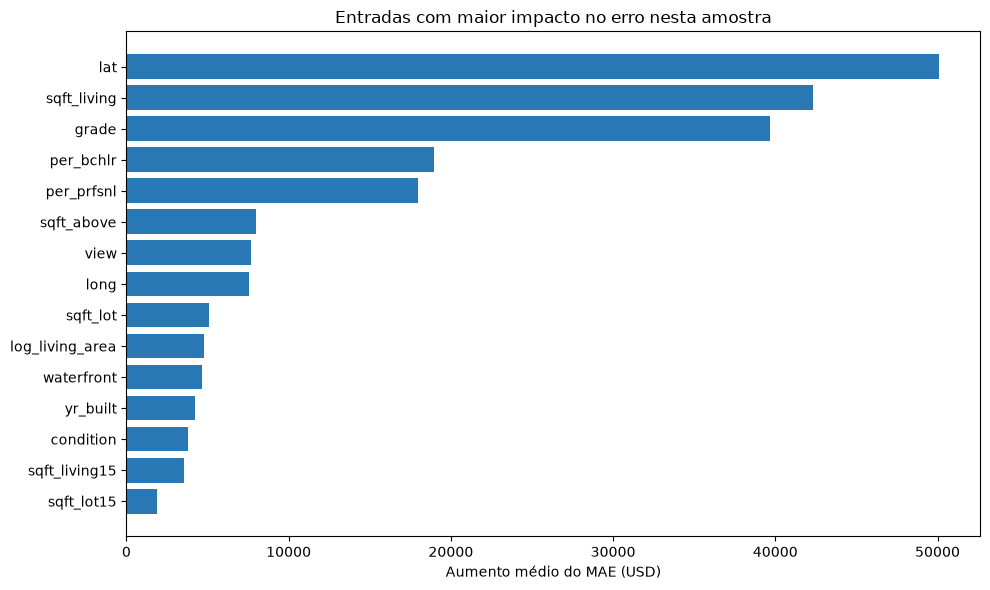

In [9]:
# Embaralha cada entrada para medir a perda de desempenho, sem retreinar.
amostra = variaveis.loc[teste, colunas_modelo].sample(n=min(AMOSTRA_IMPORTANCIA, len(teste)), random_state=SEMENTE)
pd.DataFrame({"source_row": amostra.index}).to_csv(PASTA_RESULTADOS / "avaliacao_amostra_importancia.csv", index=False)
with threadpool_limits(limits=LIMITE_THREADS):
    importancia = permutation_importance(modelo, amostra, precos.loc[amostra.index],
        scoring="neg_mean_absolute_error", n_repeats=REPETICOES_IMPORTANCIA, random_state=SEMENTE, n_jobs=1)
importancias = pd.DataFrame({"feature": colunas_modelo, "aumento_MAE": importancia.importances_mean,
                            "desvio_repeticoes": importancia.importances_std}).sort_values("aumento_MAE", ascending=False)
importancias.to_csv(PASTA_RESULTADOS / "avaliacao_importancias.csv", index=False)
exibir(importancias.head(15).round(2))
figura, eixo = plt.subplots(figsize=(10, 6))
principais = importancias.head(15).sort_values("aumento_MAE")
eixo.barh(principais["feature"], principais["aumento_MAE"], color="#2878B5")
eixo.set(title="Entradas com maior impacto no erro nesta amostra", xlabel="Aumento médio do MAE (USD)")
eixo.grid(False)
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "avaliacao_importancias.png", dpi=150)
plt.show()

**Como interpretar:** aumento maior do MAE indica que o modelo depende mais daquela entrada para prever nesta amostra. Um valor próximo de zero não comprova inutilidade. As três repetições mostram variação do embaralhamento, não um intervalo de confiança do desempenho futuro.

**Limitações:** entradas correlacionadas podem compartilhar informação. Embaralhar uma área sem alterar sua razão ou seu log, ou um indicador sem os demais do CEP, pode criar combinações irreais. O ranking é diagnóstico, não uma recomendação automática para excluir colunas. Não utilizaremos este teste para selecionar novamente as features. [Referência: importância por permutação](https://scikit-learn.org/stable/modules/permutation_importance.html).

**Resultado:** `lat`, `sqft_living` e `grade` lideraram o aumento do MAE ao serem embaralhadas, seguidas de `per_bchlr` e `per_prfsnl`. Isso indica dependência do modelo de localização, área e outros indicadores disponíveis, sob as limitações descritas. A aparição da demografia reforça a necessidade de confirmar sua origem e disponibilidade na época das vendas. Não comprova que escolaridade ou localização causem uma mudança específica de preço.

## 7. Explicando três previsões com contribuições SHAP

,source_row,price,predicted_price,erro_percentual
2987,14906,263950.0,243663.94,7.69
1271,6380,356000.0,433094.31,21.66
1852,9204,1065000.0,824849.20,22.55


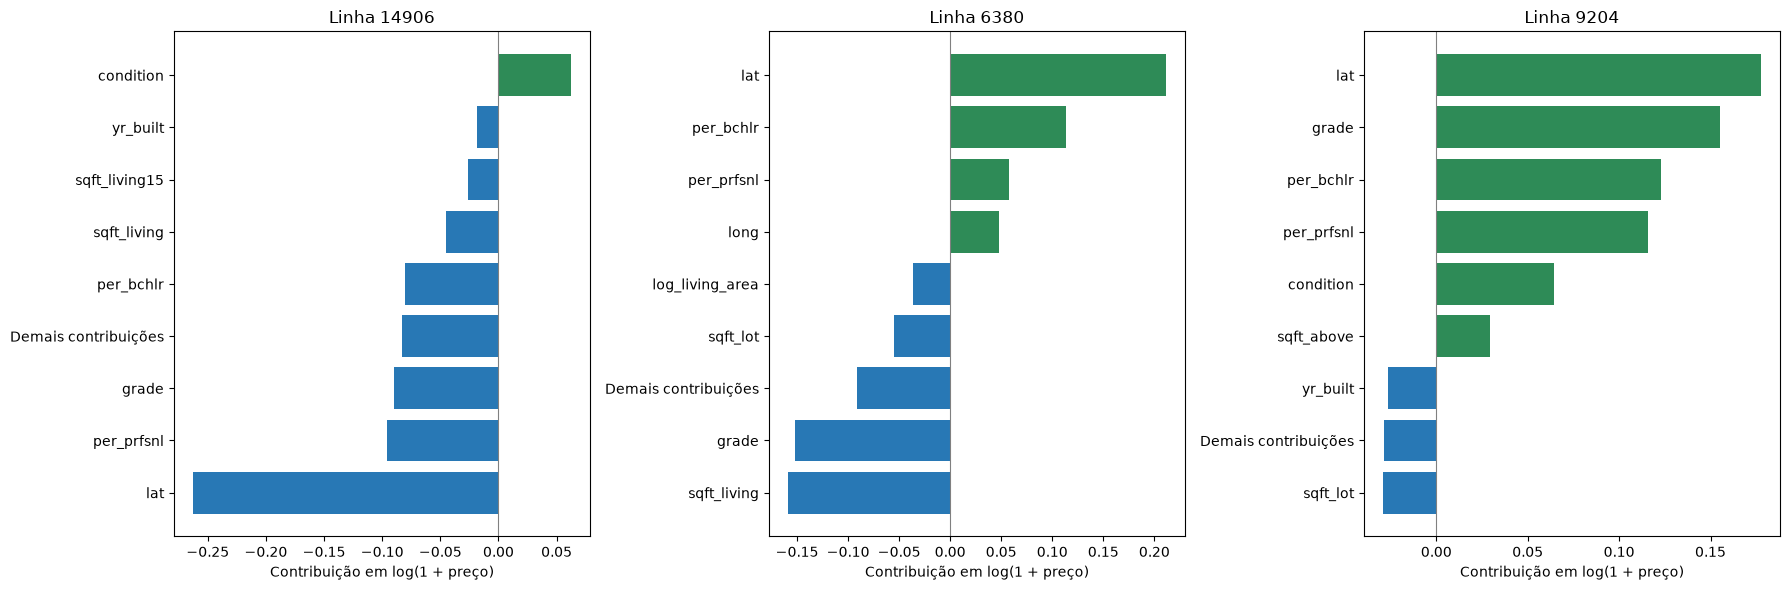

In [10]:
# Escolhe exemplos por preço previsto, sem selecionar os menores erros.
ordenados = resultados.sort_values(["predicted_price", "source_row"])
posicoes = [round((len(ordenados) - 1) * q) for q in [0.1, 0.5, 0.9]]
exemplos = ordenados.iloc[posicoes].copy()
pipeline_ajustado = modelo.regressor_
transformadas = pipeline_ajustado.named_steps["preparacao"].transform(variaveis.loc[exemplos["source_row"], colunas_modelo])
with threadpool_limits(limits=LIMITE_THREADS):
    contribuicoes = pipeline_ajustado.named_steps["modelo"].booster_.predict(transformadas, pred_contrib=True, num_threads=LIMITE_THREADS)
if contribuicoes.shape[1] != transformadas.shape[1] + 1:
    raise ValueError('As contribuições SHAP não correspondem às features transformadas.')
np.testing.assert_allclose(np.expm1(contribuicoes.sum(axis=1)), exemplos["predicted_price"], rtol=1e-6)
nomes = [nome.split("__", 1)[-1] for nome in transformadas.columns]
explicacoes = pd.DataFrame(contribuicoes[:, :-1], columns=nomes)
explicacoes.insert(0, "source_row", exemplos["source_row"].to_numpy())
explicacoes["valor_base_log"] = contribuicoes[:, -1]
explicacoes.to_csv(PASTA_RESULTADOS / "avaliacao_shap_local.csv", index=False)
exibir(exemplos[["source_row", "price", "predicted_price", "erro_percentual"]].round(2))
figura, eixos = plt.subplots(1, 3, figsize=(18, 6))
for indice, eixo in enumerate(eixos):
    valores = pd.Series(contribuicoes[indice, :-1], index=nomes)
    selecionados = valores.loc[valores.abs().nlargest(8).index]
    selecionados.loc["Demais contribuições"] = valores.sum() - selecionados.sum()
    selecionados = selecionados.sort_values()
    eixo.barh(selecionados.index, selecionados.values,
              color=["#2878B5" if v < 0 else "#2E8B57" for v in selecionados.values])
    eixo.axvline(0, color="gray", linewidth=0.8)
    eixo.set(title=f"Linha {int(exemplos.iloc[indice]['source_row'])}", xlabel="Contribuição em log(1 + preço)")
    eixo.grid(False)
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "avaliacao_shap_local.png", dpi=150)
plt.show()

**Como ler:** verde indica contribuição que eleva a previsão em relação ao valor de referência do modelo; azul indica contribuição que a reduz. Escolhemos exemplos próximos dos percentis 10, 50 e 90 do preço previsto, não casos selecionados para parecerem bons.

Como o modelo aprende o log do preço, **as barras não são valores monetários**. Valor de referência em log + todas as contribuições = previsão em log; aplicar `expm1` retorna ao preço. O código confere essa igualdade. “Demais contribuições” reúne as entradas fora das oito principais. Isso explica o cálculo do modelo, não quanto uma reforma ou mudança de bairro causaria no preço. [Referência: contribuições do LightGBM](https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.Booster.html#lightgbm.Booster.predict).

**Resultado:** as linhas 14906, 6380 e 9204 tiveram previsões de aproximadamente 243.664, 433.094 e 824.849, para preços reais de 263.950, 356.000 e 1.065.000. Há exemplos de subestimação e superestimação. No primeiro, `lat` contribui para reduzir a previsão; no terceiro, `lat` e `grade` contribuem para aumentá-la em relação à referência. Mesmo assim, o terceiro imóvel foi subestimado: explicar a previsão não significa demonstrar que ela esteja correta.

## 8. Prevendo os 100 exemplos futuros com o modelo avaliado

In [11]:
# Refaz a preparação por linha e confere os arquivos preparados no notebook 03.
colunas_entrada = contrato["colunas_entrada_antes_derivadas"]
def criar_variaveis(tabela):
    if not (tabela.columns.is_unique):
        raise ValueError('Existem nomes de colunas duplicados.')
    faltantes = sorted(set(colunas_entrada) - set(tabela.columns))
    if faltantes:
        raise ValueError(f"Colunas obrigatórias ausentes: {faltantes}")
    resultado = tabela.loc[:, colunas_entrada].copy()
    resultado["zipcode"] = resultado["zipcode"].astype("string").str.strip()

    # Preserva ausência ou valores negativos nos indicadores derivados.
    resultado["has_recorded_basement"] = (
        resultado["sqft_basement"].gt(0).astype(float)
        .where(resultado["sqft_basement"].ge(0))
    )
    resultado["has_renovation_year"] = (
        resultado["yr_renovated"].gt(0).astype(float)
        .where(resultado["yr_renovated"].ge(0))
    )

    # Só divide quando os denominadores são positivos.
    area_valida = resultado["sqft_living"].where(resultado["sqft_living"].gt(0))
    quartos_validos = resultado["bedrooms"].where(resultado["bedrooms"].gt(0))
    resultado["basement_area_ratio"] = resultado["sqft_basement"].where(resultado["sqft_basement"].ge(0)) / area_valida
    resultado["living_area_per_bedroom"] = resultado["sqft_living"].where(resultado["sqft_living"].ge(0)) / quartos_validos
    resultado["bathrooms_per_bedroom"] = resultado["bathrooms"].where(resultado["bathrooms"].ge(0)) / quartos_validos

    # A transformação logarítmica não altera as áreas originais.
    resultado["log_living_area"] = np.log1p(resultado["sqft_living"].where(resultado["sqft_living"].ge(0)))
    resultado["log_lot_area"] = np.log1p(resultado["sqft_lot"].where(resultado["sqft_lot"].ge(0)))
    # As colunas originais vêm primeiro; as derivadas seguem a ordem de criação.
    return resultado

futuros_originais = pd.read_csv(PASTA_PROJETO / "data/raw/future_unseen_examples.csv", dtype={"zipcode": "string"})
demografia = pd.read_csv(PASTA_PROJETO / "data/raw/zipcode_demographics.csv", dtype={"zipcode": "string"})
for tabela in [futuros_originais, demografia]:
    tabela["zipcode"] = tabela["zipcode"].str.strip()
if futuros_originais.columns.tolist() != colunas_baseline:
    raise ValueError('Entradas futuras ou previsões inválidas.')
futuros_com_demografia = futuros_originais.merge(demografia, on="zipcode", how="left", validate="many_to_one", sort=False)
futuros_preparados = criar_variaveis(futuros_com_demografia)
futuros_salvos = pd.read_csv(PASTA_DADOS / "features_futuros.csv", dtype={"zipcode": "string"})
pd.testing.assert_frame_equal(futuros_preparados, futuros_salvos, check_dtype=False, rtol=1e-9, atol=1e-9)
entradas_futuras = futuros_preparados.loc[:, colunas_modelo]
with threadpool_limits(limits=LIMITE_THREADS):
    previsoes_futuras = modelo.predict(entradas_futuras)
    previsao_isolada = modelo.predict(entradas_futuras.iloc[[0]])
np.testing.assert_allclose(previsao_isolada, previsoes_futuras[:1])
if not (np.isfinite(previsoes_futuras).all() and (previsoes_futuras > 0).all()):
    raise ValueError('Entradas futuras ou previsões inválidas.')
entrega = futuros_originais.copy()
entrega.insert(0, "source_row", range(len(entrega)))
entrega["predicted_price"] = previsoes_futuras
entrega["model_version"] = "avaliacao_v1"
entrega.to_csv(PASTA_PREVISOES / "future_unseen_predictions.csv", index=False)
# Mostra todas as linhas e colunas, sem abreviar a tabela.
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None):
    exibir(entrega)

,source_row,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,predicted_price,model_version
0,0,4,1.00,1680,5043,1.5,0,0,4,6,1680,0,1911,0,98118,47.5354,-122.273,1560,5765,3.270368e+05,avaliacao_v1
1,1,3,2.50,2220,6380,1.5,0,0,4,8,1660,560,1931,0,98115,47.6974,-122.313,950,6380,6.210419e+05,avaliacao_v1
2,2,3,2.25,1630,10962,1.0,0,0,4,8,1100,530,1977,0,98030,47.3801,-122.166,1830,8470,2.663578e+05,avaliacao_v1
3,3,5,2.50,1710,9720,2.0,0,0,4,8,1710,0,1974,0,98005,47.5903,-122.157,2270,9672,5.843716e+05,avaliacao_v1
4,4,2,1.00,850,6370,1.0,0,0,3,6,850,0,1951,0,98126,47.5198,-122.373,850,5170,2.327776e+05,avaliacao_v1
5,5,4,2.75,2630,4501,2.0,0,0,3,8,2630,0,2015,0,98028,47.7748,-122.244,2380,4599,4.969033e+05,avaliacao_v1
6,6,4,1.75,2290,7380,1.0,0,0,3,7,1390,900,1963,0,98178,47.5034,-122.245,1170,7381,2.897009e+05,avaliacao_v1
7,7,4,2.00,1730,9139,2.0,0,0,3,8,1730,0,1957,0,98125,47.7181,-122.316,1410,7311,4.232039e+05,avaliacao_v1
8,8,3,1.75,2190,8500,1.0,0,0,4,9,2190,0,1957,0,98112,47.6400,-122.285,2850,8868,1.320939e+06,avaliacao_v1
9,9,3,1.75,1850,22767,1.5,0,4,5,6,1850,0,1908,0,98074,47.6144,-122.067,2700,17906,6.148398e+05,avaliacao_v1


**Por que refazer a preparação:** conferimos que a junção por CEP e as sete derivadas reproduzem os arquivos anteriores, preservando a ordem original. O pipeline ajustado aplica sua própria imputação e codificação, sem aprender nada nos futuros. A conferência de uma previsão isolada verifica que a presença de outras casas no lote não muda seu resultado.

Os 100 preços são previsões, não preços recuperados por correspondência com o histórico. Não calculamos MAE para esses exemplos porque não há preço real fornecido. Não treinamos novamente com o teste antes de gerar este arquivo: o estimador é o mesmo avaliado nesta etapa.

**Resultado:** foram geradas 100 previsões positivas e finitas, preservando a ordem original. Elas variam de aproximadamente 176.625 a 2.198.831. A igualdade entre uma previsão isolada e a mesma linha no lote foi conferida. Esses valores não têm uma métrica de acerto porque o arquivo futuro não fornece o preço real.

**Exibição completa:** a tabela acima mostra os 100 imóveis e as 21 colunas do arquivo exportado: 18 características originais, `source_row`, `predicted_price` e `model_version`. Use a rolagem horizontal do visualizador para consultar as colunas à direita.

## 9. Ficha do modelo e próximos passos

In [12]:
# Registra métricas, origem dos artefatos e limites da interpretação.
ficha = {"currency": "USD", "currency_basis": "premissa pelo contexto de Seattle; sem conversão cambial", "model_version": "avaliacao_v1", "modelo": configuracao["modelo"],
    "configuracao_selecao": configuracao["versao"], "colunas_ordenadas": colunas_modelo,
    "parametros": configuracao["parametros"], "transformacao_alvo": "log1p_expm1",
    "versoes": {**configuracao["versoes"], "python": platform.python_version(), "joblib": joblib.__version__},
    "treino": registro["treino"], "teste": registro["teste"], "test_evaluated": True,
    "metricas_teste": metricas.to_dict(orient="records"), "reajustado_com_teste": False,
    "artefatos_sha256": registro["artefatos_sha256"],
    "previsoes_futuras_sha256": hash_arquivo(PASTA_PREVISOES / "future_unseen_predictions.csv"),
    "fontes_futuras_sha256": {nome: hash_arquivo(PASTA_PROJETO / nome) for nome in [
        "data/raw/future_unseen_examples.csv", "data/raw/zipcode_demographics.csv", "data/processed/features_futuros.csv"]},
    "explicabilidade": {"permutacao_amostra": len(amostra), "repeticoes": REPETICOES_IMPORTANCIA,
                        "shap_exemplos": exemplos["source_row"].tolist(), "escala_shap": "log1p_price"},
    "limites": ["EDA prévia examinou todo o histórico", "disponibilidade histórica da demografia a confirmar",
        "teste temporal único não garante outros períodos ou regiões", "importância não demonstra causalidade",
        "não há limite de erro aprovado pelo negócio", "futuros sobrepõem características do histórico"],
    "interface_artefato": "50 features já enriquecidas e derivadas; merge e criação de features externos ao joblib",
    "proxima_etapa": "documentar empacotamento e API no notebook 07; implementação e deploy fora do escopo atual"}
(PASTA_ARTEFATOS / "model_card.json").write_text(json.dumps(ficha, indent=2, ensure_ascii=False), encoding="utf-8")
exibir(pd.DataFrame({"item": ["Modelo", "Treino", "Teste", "Previsões futuras", "Novo ajuste com teste"],
    "valor": [ficha["modelo"], len(treino), len(teste), len(entrega), False]}))

,item,valor
0,Modelo,LightGBM
1,Treino,17191
2,Teste,4331
3,Previsões futuras,100
4,Novo ajuste com teste,False


**O que fica pronto:** o pipeline avaliado, a referência Ridge, métricas, previsões e os registros que ligam esses resultados aos dados e parâmetros utilizados. O arquivo `modelo_avaliado.joblib` recebe as 50 features prontas; o notebook 07 documenta como a junção e a criação das derivadas seriam integradas ao empacotamento, sem implementar a API.

**Decisão:** esta etapa descreve desempenho e limitações, sem declarar aprovação automática para produção. Melhorias sugeridas pelos erros devem ser tratadas como novos experimentos com uma avaliação futura adequada; não mudaremos o modelo para melhorar o resultado neste mesmo teste.

## Conclusão para stakeholders

O modelo reduziu o MAE do teste em 27,48% frente ao Ridge e colocou 80,56% das previsões dentro de ±20% do preço real. Entretanto, o erro de teste foi maior que o de validação, há subestimação média e o desempenho piora em imóveis acima de 1 milhão. Não há um limite de negócio aprovado que permita declarar o resultado suficiente para produção.

Foram salvos o modelo efetivamente avaliado e as 100 previsões futuras geradas por ele. A etapa 07 documenta a proposta de empacotamento do fluxo de enriquecimento, criação de variáveis e previsão em uma API. API, Docker e deploy não foram implementados. A implantação precisa considerar as pendências de dados, os segmentos com erros elevados e as tolerâncias definidas com os responsáveis pelo uso.

